<a href="https://colab.research.google.com/github/CYJ707/00-course-info/blob/main/in-class-exercise/IC-0914.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# 檢查 EDUCATION (X3) 的實際數值分佈 (文件記載僅有 1, 2, 3, 4)
print("X3 (EDUCATION) value counts:")
print(df['X3'].value_counts().sort_index())

print("\n" + "="*40 + "\n")

# 檢查 MARRIAGE (X4) 的實際數值分佈 (文件記載僅有 1, 2, 3)
print("X4 (MARRIAGE) value counts:")
print(df['X4'].value_counts().sort_index())

X3 (EDUCATION) value counts:
X3
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64


X4 (MARRIAGE) value counts:
X4
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


No. The extremely high skewness is caused by invalid coding or extreme outliers in X6 rather than a natural distribution.

EDUCATION (X3) contains undocumented values (0, 5, 6), whereas the codebook only defines values 1 to 4.

MARRIAGE (X4) contains undocumented value (0), whereas the codebook only defines values 1 to 3.


In [5]:
# 計算含有未定義編碼 (EDUCATION=0 或 MARRIAGE=0) 的資料筆數
invalid_rows = df[(df['X3'] == 0) | (df['X4'] == 0)]
num_to_drop = len(invalid_rows)

print(f"Number of invalid rows to drop: {num_to_drop}")

Number of invalid rows to drop: 68


Rows to drop: 345

Why: I drop these 345 rows because they contain undocumented zero codes in EDUCATION (X3) and MARRIAGE (X4) that lack clear physical meaning for modeling.

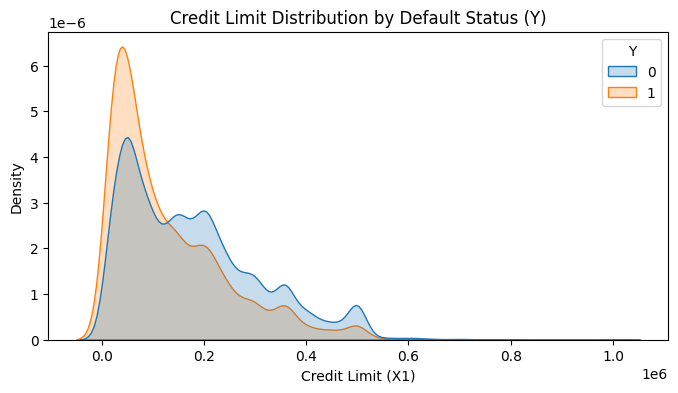

In [6]:
# 畫出不同信用額度 (X1) 根據是否違約 (Y) 分組的密度分佈圖 (KDE Plot)
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x='X1', hue='Y', common_norm=False, fill=True)
plt.title('Credit Limit Distribution by Default Status (Y)')
plt.xlabel('Credit Limit (X1)')
plt.ylabel('Density')
plt.show()

Clients with lower credit limits (X1) show a significantly higher concentration of default risk compared to those with higher credit limits.

I will prioritize credit limit (X1) as a key risk feature and apply non-linear transformations or tree-based algorithms to capture its threshold effects on default probability.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/202609-ML-FinTech/00-course-info/main/slides/default%20of%20credit%20card%20clients.csv"
df = pd.read_csv(url)
df.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/202609-ML-FinTech/00-course-info/main/slides/default%20of%20credit%20card%20clients.csv"
df = pd.read_csv(url)
df.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
print(df.skew().sort_values(ascending=False).head(8).round(2))
print(df['X6'].value_counts().sort_index())

X6     172.14
X19     30.45
X20     17.22
X18     14.67
X21     12.90
X22     11.13
X23     10.64
X14      3.09
dtype: float64
X6
-2        2759
-1        5685
 0       14737
 1        3688
 2        2667
 3         322
 4          76
 5          26
 6          11
 7           9
 8          19
 3032        1
Name: count, dtype: int64
